In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, r2_score, confusion_matrix, ConfusionMatrixDisplay

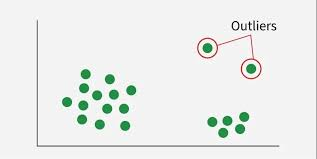

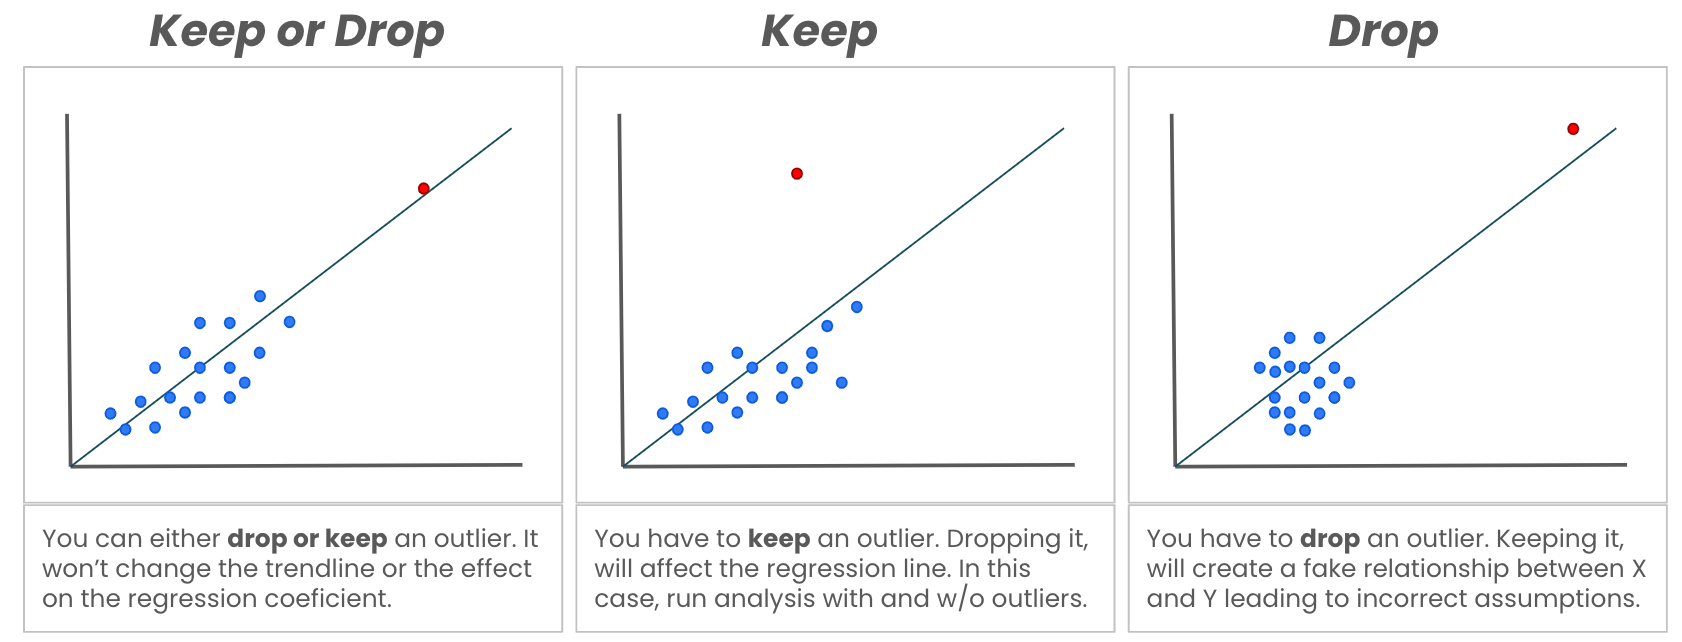

Ways to treat outliers:

    a) Trim the outliers i.e. delete them. Can lead to thin dataset post removal in case outliers are very high. Very Fast

    b) Capping: Convert all outliers that are less than a decided minimum value that value and all outliers that are greater than a decided maximum value that max value

    c) Consider outlier as missing and treat then as NaN

Detecting outliers:

    a) If column is a normal distribution, all observations not between (mean +- 3*SD) is an outlier.

    b) If data is skewed, use Interquartile proximity using boxplots. all values outside box plot are outliers

    c) If any observation is > 99%ile value or observation is < 2.5%ile value, it is an outlier

# **Outlier detection and removal using Z-Score**

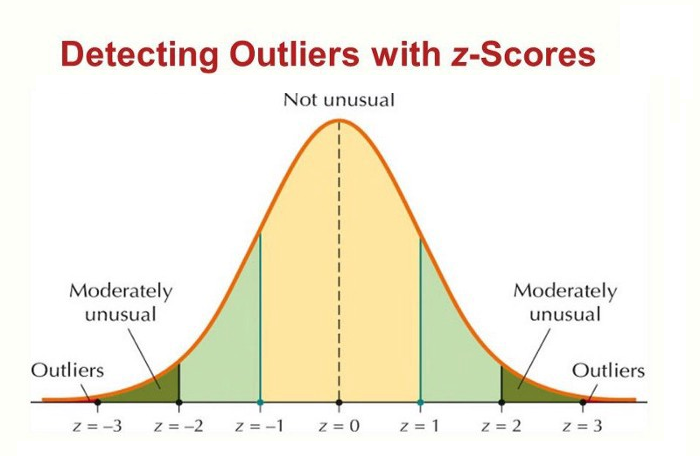

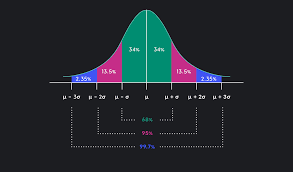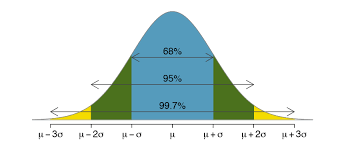

Data must be Normally Distributed

In [2]:
data = pd.read_csv("placement.csv")
data.sample(5)

,cgpa,placement_exam_marks,placed
741,7.58,66.0,0
742,6.79,29.0,0
231,6.40,35.0,0
871,6.56,60.0,0
102,5.92,22.0,1


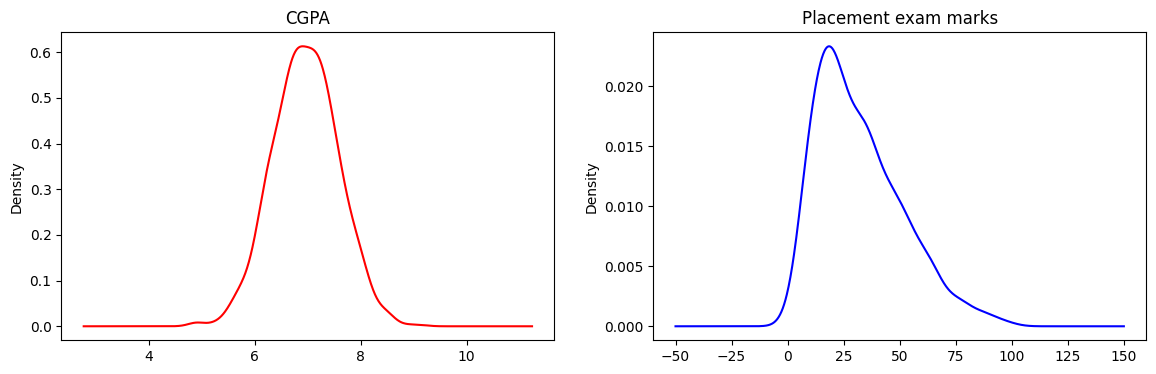

In [5]:
plt.figure(figsize=(14,4))

plt.subplot(121)
data["cgpa"].plot(kind="kde", color="red")
plt.title("CGPA")

plt.subplot(122)
data["placement_exam_marks"].plot(kind="kde", color="blue")
plt.title("Placement exam marks")

plt.show()

In [10]:
upper_limit = data["cgpa"].mean() + (3 * data["cgpa"].std())
lower_limit = data["cgpa"].mean() - (3 * data["cgpa"].std())

print(f"Upper Limit: {upper_limit}")
print(f"Lower Limit: {lower_limit}")

Upper Limit: 8.808933625397168
Lower Limit: 5.113546374602832


In [11]:
data["cgpa"].describe()

,cgpa
count,1000.000000
mean,6.961240
std,0.615898
min,4.890000
25%,6.550000
50%,6.960000
75%,7.370000
max,9.120000


In [13]:
outliers = data[(data["cgpa"]>upper_limit) | (data["cgpa"]<lower_limit)]
outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [14]:
# Trimming

trimmed_data = data[(data["cgpa"] < upper_limit) & (data["cgpa"] > lower_limit)]
trimmed_data

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [19]:
# Capping
data["cgpa_capped"] = np.where(
    data["cgpa"] > upper_limit,
    upper_limit,
    np.where(
        data["cgpa"] < lower_limit,
        lower_limit,
        data["cgpa"]
    )
)

data.sample(10)

data[(data["cgpa"]>upper_limit) | (data["cgpa"]<lower_limit)]

,cgpa,placement_exam_marks,placed,cgpa_capped
485,4.92,44.0,1,5.113546
995,8.87,44.0,1,8.808934
996,9.12,65.0,1,8.808934
997,4.89,34.0,0,5.113546
999,4.90,10.0,1,5.113546


# **Outlier detection and removal using Z-Score**

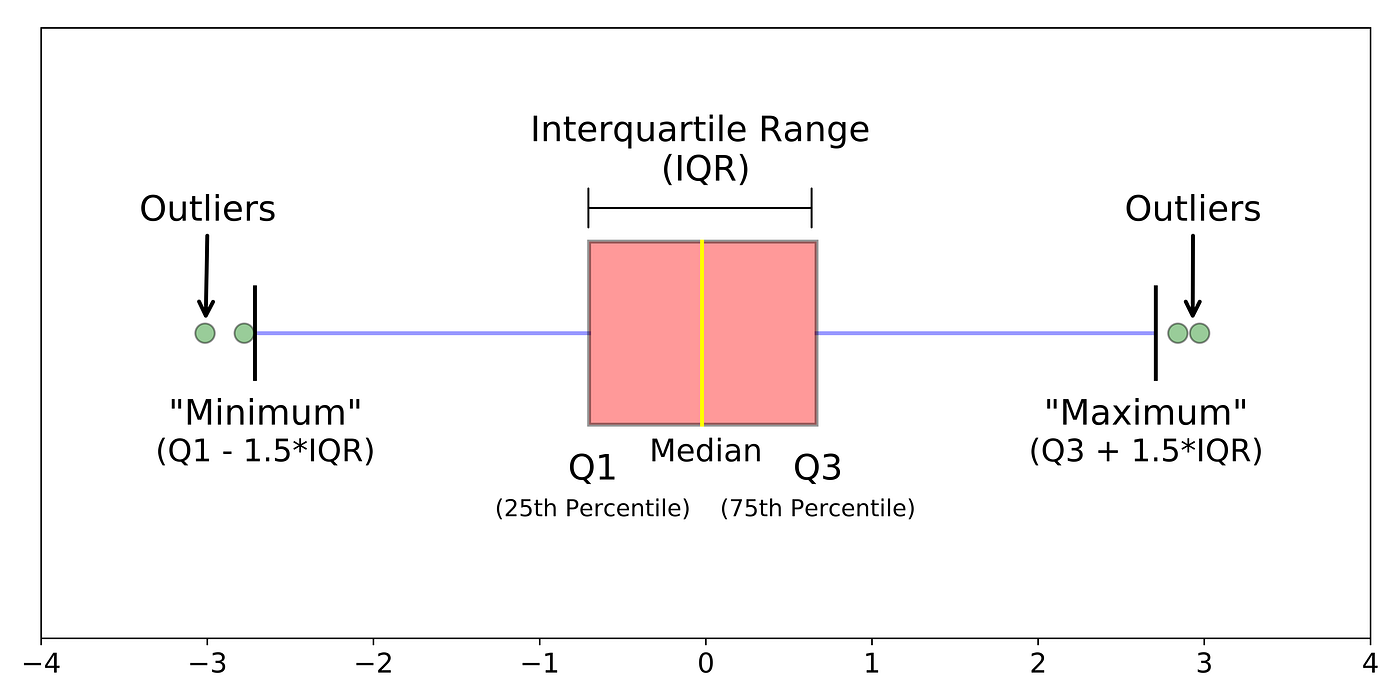

In [39]:
data = pd.read_csv("placement.csv")
data.sample(10)

,cgpa,placement_exam_marks,placed
163,6.77,42.0,1
217,6.92,16.0,0
514,7.36,15.0,0
657,7.60,23.0,0
971,6.69,18.0,1
685,6.05,87.0,1
410,7.36,37.0,1
556,6.70,15.0,1
635,6.69,10.0,0
24,6.44,11.0,0


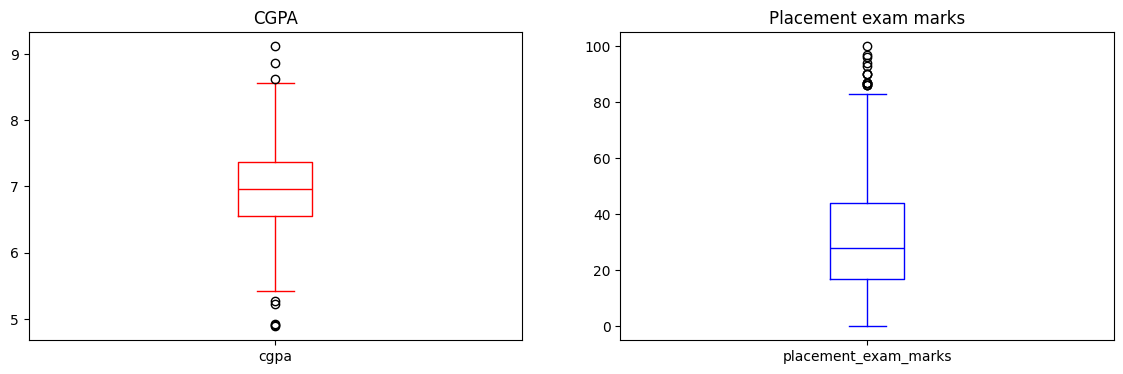

In [40]:
plt.figure(figsize=(14,4))

plt.subplot(121)
data["cgpa"].plot(kind="box", color="red")
plt.title("CGPA")

plt.subplot(122)
data["placement_exam_marks"].plot(kind="box", color="blue")
plt.title("Placement exam marks")

plt.show()

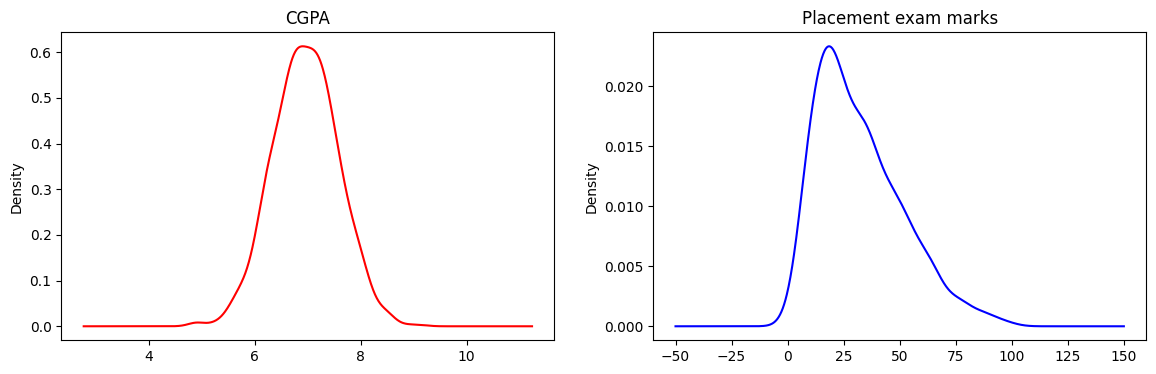

In [41]:
plt.figure(figsize=(14,4))

plt.subplot(121)
data["cgpa"].plot(kind="kde", color="red")
plt.title("CGPA")

plt.subplot(122)
data["placement_exam_marks"].plot(kind="kde", color="blue")
plt.title("Placement exam marks")

plt.show()

In [42]:
# Calculating quartiles and IQR

Q1 = data["placement_exam_marks"].quantile(0.25)
Q3 = data["placement_exam_marks"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

print(f"Upper Limit: {upper_limit}")
print(f"Lower Limit: {lower_limit}")

Upper Limit: 84.5
Lower Limit: -23.5


In [43]:
data["placement_exam_marks"].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


In [44]:
outliers = data[(data["placement_exam_marks"] > upper_limit) | (data["placement_exam_marks"] < lower_limit)]
outliers

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [45]:
print(f"No. of outliers: {len(outliers)}")

No. of outliers: 15


In [46]:
# Trimming

trimmed_data = data[(data["placement_exam_marks"] > lower_limit) & (data["placement_exam_marks"] < upper_limit)]
trimmed_data

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


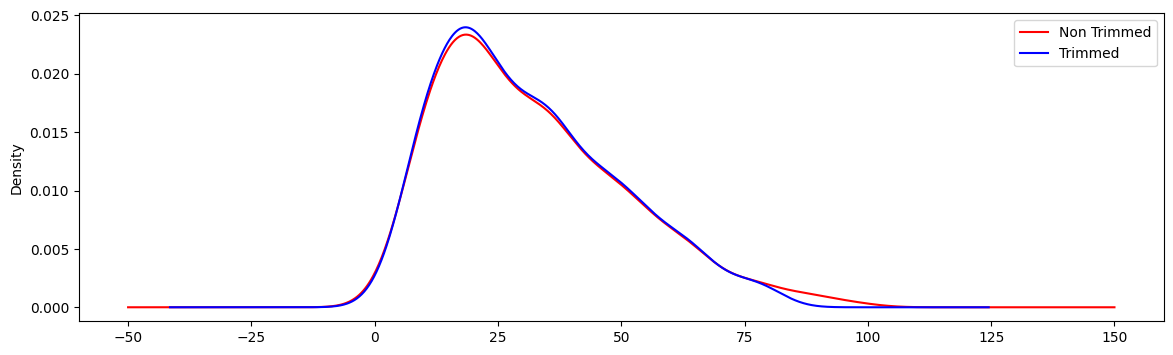

In [49]:
plt.figure(figsize=(14,4))

data["placement_exam_marks"].plot(kind="kde", color="red", label="Non Trimmed")
trimmed_data["placement_exam_marks"].plot(kind="kde", color="blue", label="Trimmed")

plt.legend()
plt.show()

In [47]:
# Capping

data["placement_exam_marks_new"] = np.where(
    data["placement_exam_marks"] > upper_limit,
    upper_limit,
    np.where(
        data["placement_exam_marks"] > lower_limit,
        data["placement_exam_marks"],
        lower_limit
    )
)

data.sample(10)

,cgpa,placement_exam_marks,placed,placement_exam_marks_new
669,6.94,8.0,1,8.0
510,6.84,34.0,1,34.0
138,7.53,8.0,1,8.0
617,7.08,22.0,0,22.0
247,6.25,49.0,0,49.0
332,7.03,39.0,0,39.0
490,7.34,32.0,0,32.0
318,6.74,60.0,0,60.0
959,6.76,27.0,1,27.0
313,6.51,18.0,1,18.0


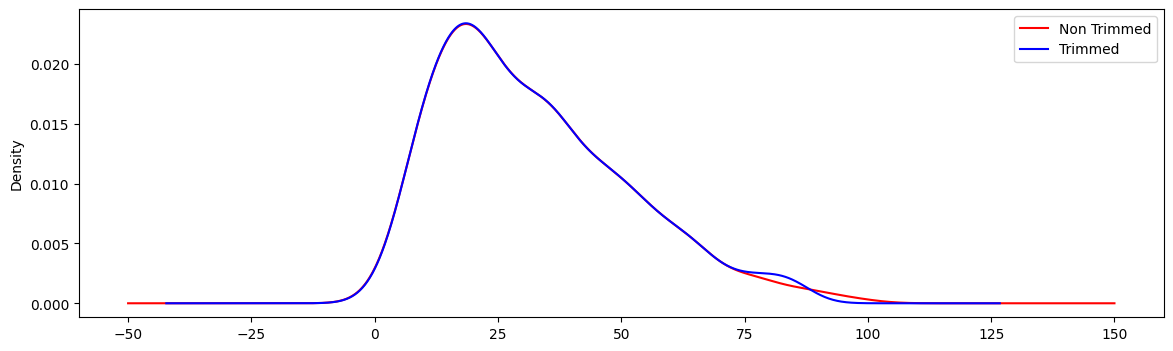

In [50]:
plt.figure(figsize=(14,4))

data["placement_exam_marks"].plot(kind="kde", color="red", label="Non Trimmed")
data["placement_exam_marks_new"].plot(kind="kde", color="blue", label="Trimmed")

plt.legend()
plt.show()